In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/vacancies.csv')
df.head()

,vacancy_id,salary_from,salary_to,experience,city,employment_type
0,37351176,60000.0,70000.0,Нет опыта,Екатеринбург,Удалённая работа
1,53503796,140000.0,210000.0,От 1 года до 3 лет,Москва,Полная занятость
2,20319022,NaN,NaN,Более 6 лет,Москва,Полная занятость
3,40619665,145000.0,215000.0,От 1 года до 3 лет,Нижний Новгород,Полная занятость
4,14675717,NaN,NaN,Более 6 лет,Москва,Полная занятость


# Задача 1. Анализ зарплат
## 1. Первичный анализ

Проверим размер датасета, типы данных, пропуски,
распределение вакансий по опыту и базовые характеристики зарплатных полей.

In [ ]:
df.shape

(100000, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   vacancy_id       100000 non-null  int64  
 1   salary_from      68385 non-null   float64
 2   salary_to        69219 non-null   float64
 3   experience       100000 non-null  object 
 4   city             100000 non-null  object 
 5   employment_type  100000 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 4.6+ MB


In [ ]:
df.isna().sum()

,0
vacancy_id,0
salary_from,31615
salary_to,30781
experience,0
city,0
employment_type,0


In [ ]:
df['experience'].value_counts(dropna=False)

,count
experience,
От 1 года до 3 лет,39958
От 3 до 6 лет,29938
Более 6 лет,15138
Нет опыта,14966


In [ ]:
df[['salary_from', 'salary_to']].describe()

,salary_from,salary_to
count,6.838500e+04,6.921900e+04
mean,4.547105e+05,6.155720e+05
std,2.466358e+06,3.377744e+06
min,5.000000e+03,7.000000e+03
25%,8.500000e+04,1.100000e+05
50%,1.200000e+05,1.700000e+05
75%,1.900000e+05,2.600000e+05
max,5.950000e+07,8.950000e+07


## 2. Проверка качества зарплатных данных

Проверим, встречаются ли некорректные вилки зарплат,
аномально большие или маленькие значения и насколько часто у вакансий указана только одна граница зарплаты.

In [ ]:
((df['salary_from'].notna()) & (df['salary_to'].notna()) &
 (df['salary_from'] > df['salary_to'])).sum()

np.int64(987)

In [ ]:
df[['salary_from', 'salary_to']].max()

,0
salary_from,59500000.0
salary_to,89500000.0


In [ ]:
df[['salary_from', 'salary_to']].min()

,0
salary_from,5000.0
salary_to,7000.0


In [ ]:
df[['salary_from', 'salary_to']].quantile([0.01, 0.25, 0.5, 0.75, 0.99])

,salary_from,salary_to
0.01,30000.0,40000.0
0.25,85000.0,110000.0
0.50,120000.0,170000.0
0.75,190000.0,260000.0
0.99,12500000.0,17500000.0


In [4]:
pd.DataFrame({
    'both_present': [(df['salary_from'].notna() & df['salary_to'].notna()).sum()],
    'only_from': [(df['salary_from'].notna() & df['salary_to'].isna()).sum()],
    'only_to': [(df['salary_from'].isna() & df['salary_to'].notna()).sum()],
    'both_missing': [(df['salary_from'].isna() & df['salary_to'].isna()).sum()]
})

,both_present,only_from,only_to,both_missing
0,63194,5191,6025,25590


### Наблюдения

В данных присутствуют потенциальные ошибки парсинга и выбросы:
в части записей нижняя граница зарплаты превышает верхнюю,
а экстремальные значения сильно отличаются от основной массы данных.

Перед расчётом описательных статистик необходимо определить правила очистки
и способ формирования единой оценки зарплаты для вакансии.

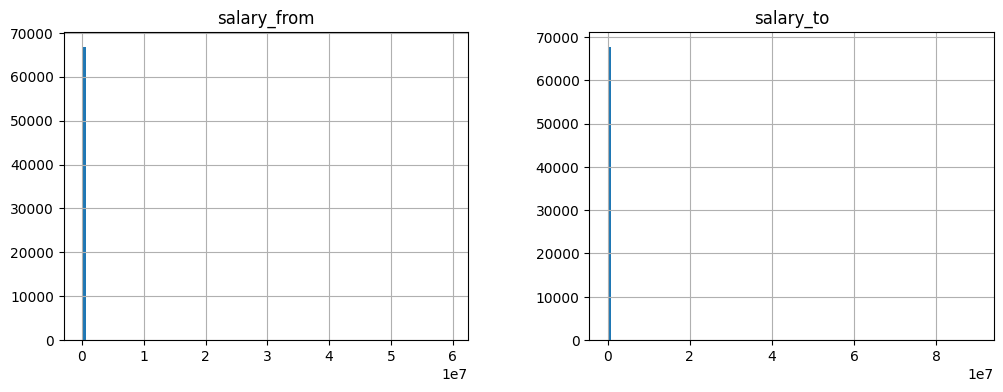

In [5]:
df[['salary_from', 'salary_to']].hist(
    bins=100,
    figsize=(12, 4)
)

plt.show()

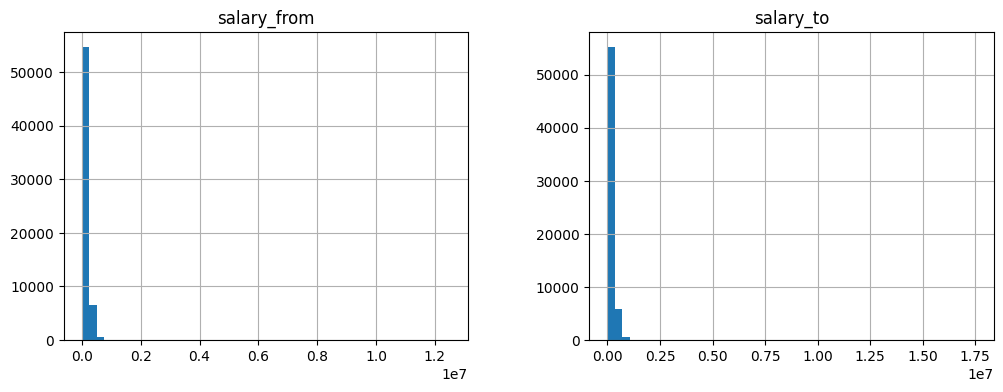

In [6]:
salary_from_99 = df['salary_from'].quantile(0.99)
salary_to_99 = df['salary_to'].quantile(0.99)

df[
    (df['salary_from'] <= salary_from_99) &
    (df['salary_to'] <= salary_to_99)
][['salary_from', 'salary_to']].hist(
    bins=50,
    figsize=(12, 4)
)

plt.show()

### Анализ верхнего хвоста распределения

Даже после отсечения верхнего 1% распределение остаётся сильно скошенным.
Проверим крупнейшие значения зарплат и частоту их появления, чтобы понять,
являются ли они редкими высокими зарплатами или следствием ошибок парсинга.

In [7]:
df.sort_values('salary_from', ascending=False)[
    ['salary_from', 'salary_to', 'experience', 'city', 'employment_type']
].head(30)

,salary_from,salary_to,experience,city,employment_type
78499,59500000.0,87000000.0,От 1 года до 3 лет,Москва,Полная занятость
71705,59500000.0,81000000.0,От 1 года до 3 лет,Москва,Полная занятость
55640,59000000.0,82500000.0,От 1 года до 3 лет,Москва,Полная занятость
68232,58500000.0,88500000.0,От 1 года до 3 лет,Москва,Полная занятость
15729,57500000.0,86000000.0,От 1 года до 3 лет,Москва,Полная занятость
14400,55000000.0,89500000.0,От 1 года до 3 лет,Москва,Полная занятость
58839,55000000.0,66500000.0,Более 6 лет,Москва,Полная занятость
64331,55000000.0,83500000.0,От 1 года до 3 лет,Москва,Полная занятость
27230,53500000.0,39000000.0,Более 6 лет,Москва,Удалённая работа
25567,53000000.0,64000000.0,Более 6 лет,Москва,Полная занятость


In [13]:
df.sort_values('salary_to', ascending=False)[
    ['salary_from', 'salary_to', 'experience', 'city', 'employment_type']
].head(30)

,salary_from,salary_to,experience,city,employment_type
14400,55000000.0,89500000.0,От 1 года до 3 лет,Москва,Полная занятость
68232,58500000.0,88500000.0,От 1 года до 3 лет,Москва,Полная занятость
78499,59500000.0,87000000.0,От 1 года до 3 лет,Москва,Полная занятость
15729,57500000.0,86000000.0,От 1 года до 3 лет,Москва,Полная занятость
64331,55000000.0,83500000.0,От 1 года до 3 лет,Москва,Полная занятость
52889,51500000.0,83500000.0,От 1 года до 3 лет,Москва,Удалённая работа
55640,59000000.0,82500000.0,От 1 года до 3 лет,Москва,Полная занятость
71705,59500000.0,81000000.0,От 1 года до 3 лет,Москва,Полная занятость
98080,47000000.0,74500000.0,От 1 года до 3 лет,Санкт-Петербург,Полная занятость
36737,47000000.0,74000000.0,От 1 года до 3 лет,Москва,Удалённая работа


In [14]:
df[df['salary_from'] > 1_000_000][
    ['salary_from', 'salary_to']
].head(50)

,salary_from,salary_to
125,7500000.0,11500000.0
167,9500000.0,12000000.0
176,8000000.0,11500000.0
277,8000000.0,12500000.0
561,12500000.0,16000000.0
638,11000000.0,15000000.0
702,25500000.0,34500000.0
739,40000000.0,59000000.0
814,8500000.0,9000000.0
902,22000000.0,27000000.0


In [10]:
df[df['salary_to'] > 1_000_000][
    ['salary_from', 'salary_to']
].head(50)

,salary_from,salary_to
125,7500000.0,11500000.0
167,9500000.0,12000000.0
176,8000000.0,11500000.0
277,8000000.0,12500000.0
561,12500000.0,16000000.0
638,11000000.0,15000000.0
702,25500000.0,34500000.0
739,40000000.0,59000000.0
814,8500000.0,9000000.0
902,22000000.0,27000000.0


In [11]:
df.loc[df['salary_from'] > 1_000_000, 'salary_from'].value_counts().head(20)

,count
salary_from,
8000000.0,66
7500000.0,65
8500000.0,62
9000000.0,57
10500000.0,57
7000000.0,56
6000000.0,56
11500000.0,53
6500000.0,53


In [12]:
df.loc[df['salary_to'] > 1_000_000, 'salary_to'].value_counts().head(20)

,count
salary_to,
11000000.0,49
10000000.0,48
12000000.0,44
9500000.0,44
10500000.0,40
12500000.0,39
11500000.0,39
8500000.0,35
19000000.0,34


In [15]:
sorted_salary = (
    df['salary_from']
    .dropna()
    .sort_values()
    .reset_index(drop=True)
)

sorted_salary.tail(200)

,salary_from
68185,23500000.0
68186,23500000.0
68187,24000000.0
68188,24000000.0
68189,24000000.0
...,...
68380,57500000.0
68381,58500000.0
68382,59000000.0
68383,59500000.0


In [16]:
df[
    (df['salary_from'] >= 500_000) &
    (df['salary_from'] <= 5_000_000)
]['salary_from'].value_counts().sort_index()

,count
salary_from,
500000.0,35
505000.0,37
510000.0,35
515000.0,30
520000.0,31
525000.0,34
530000.0,26
535000.0,32
540000.0,23


In [17]:
df[
    (df['salary_to'] >= 500_000) &
    (df['salary_to'] <= 5_000_000)
]['salary_to'].value_counts().sort_index()

,count
salary_to,
500000.0,66
505000.0,62
510000.0,62
515000.0,63
520000.0,65
...,...
3000000.0,2
3500000.0,1
4000000.0,3


### Вывод по верхнему хвосту

В распределении наблюдается выраженный разрыв: для `salary_from`
значения основной группы доходят примерно до 875 тыс., после чего
следующий кластер начинается с 2,5 млн. Для `salary_to` аналогичный
разрыв наблюдается между примерно 920 тыс. и 3 млн.

Кроме того, значения в верхнем кластере преимущественно круглые и
повторяются много раз. Это подтверждает гипотезу о систематической
ошибке масштаба при парсинге зарплат.

В дальнейшем значения выше 1 млн будут отдельно обработаны как
потенциально ошибочно масштабированные.

In [18]:
df[df['salary_from'] > 1_000_000][
    ['salary_from', 'salary_to', 'experience']
].assign(
    salary_from_scaled=lambda x: x['salary_from'] / 100,
    salary_to_scaled=lambda x: x['salary_to'] / 100
).head(20)

,salary_from,salary_to,experience,salary_from_scaled,salary_to_scaled
125,7500000.0,11500000.0,От 1 года до 3 лет,75000.0,115000.0
167,9500000.0,12000000.0,От 3 до 6 лет,95000.0,120000.0
176,8000000.0,11500000.0,От 1 года до 3 лет,80000.0,115000.0
277,8000000.0,12500000.0,От 1 года до 3 лет,80000.0,125000.0
561,12500000.0,16000000.0,От 3 до 6 лет,125000.0,160000.0
638,11000000.0,15000000.0,От 1 года до 3 лет,110000.0,150000.0
702,25500000.0,34500000.0,От 1 года до 3 лет,255000.0,345000.0
739,40000000.0,59000000.0,От 1 года до 3 лет,400000.0,590000.0
814,8500000.0,9000000.0,Нет опыта,85000.0,90000.0
902,22000000.0,27000000.0,От 3 до 6 лет,220000.0,270000.0


### Вывод по ошибке масштаба

Проверка показала, что значения из верхнего кластера после деления на 100
превращаются в реалистичные зарплатные вилки для соответствующих уровней опыта.

С учётом выраженного разрыва между основной массой значений и кластером
многомиллионных зарплат это подтверждает гипотезу о систематической ошибке
масштаба при парсинге части вакансий.

In [19]:
df_clean = df.copy()

In [21]:
scale_threshold = 2_000_000

df_clean.loc[
    df_clean['salary_from'] > scale_threshold,
    'salary_from'
] /= 100

df_clean.loc[
    df_clean['salary_to'] > scale_threshold,
    'salary_to'
] /= 100

In [22]:
df_clean[['salary_from', 'salary_to']].describe()

,salary_from,salary_to
count,68385.000000,69219.000000
mean,145144.563866,197533.350670
std,91800.114588,127826.849508
min,5000.000000,7000.000000
25%,80000.000000,105000.000000
50%,120000.000000,165000.000000
75%,185000.000000,250000.000000
max,875000.000000,920000.000000


In [23]:
df_clean[['salary_from', 'salary_to']].max()

,0
salary_from,875000.0
salary_to,920000.0


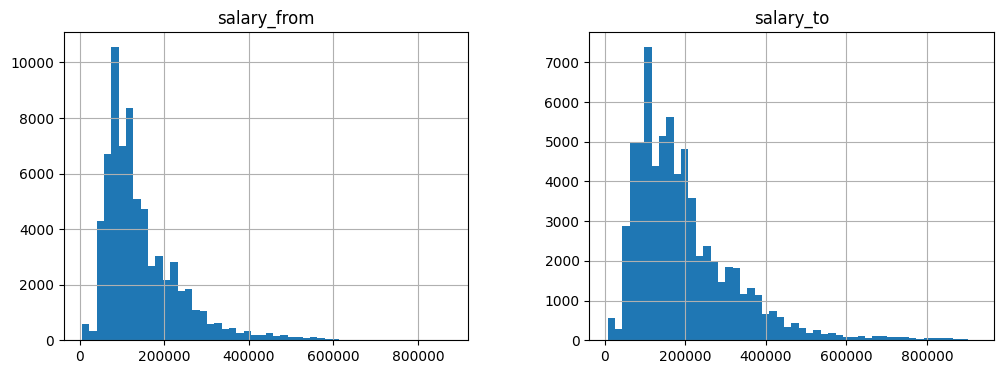

In [24]:
df_clean[['salary_from', 'salary_to']].hist(
    bins=50,
    figsize=(12, 4)
)

plt.show()

### Результат коррекции масштаба

После корректировки подозрительно больших значений распределение стало
существенно более реалистичным: экстремальные значения в десятках миллионов
исчезли, а основная форма распределения сохранилась.

Максимальные значения теперь составляют около 875 тыс. для `salary_from`
и 920 тыс. для `salary_to`, что выглядит правдоподобно для рынка вакансий аналитиков.

### Проверка нижнего хвоста распределения

После коррекции аномально больших значений отдельно проверим нижний хвост распределения.

В данных встречаются очень низкие зарплаты — от 5–7 тыс.. Такие значения могут быть как реальными для отдельных форм занятости, так и следствием ошибок парсинга или масштаба.

Поэтому перед удалением или корректировкой таких наблюдений проверим их частоту и контекст.

In [25]:
df_clean[
    (df_clean['salary_from'] < 30_000) |
    (df_clean['salary_to'] < 30_000)
][
    ['salary_from', 'salary_to', 'experience', 'city', 'employment_type']
].head(50)

,salary_from,salary_to,experience,city,employment_type
162,15000.0,20000.0,От 3 до 6 лет,Новосибирск,Полная занятость
284,20000.0,30000.0,От 3 до 6 лет,Екатеринбург,Частичная занятость
289,25000.0,25000.0,Нет опыта,Нижний Новгород,Полная занятость
564,25000.0,35000.0,От 3 до 6 лет,Москва,Полная занятость
682,9000.0,11000.0,Более 6 лет,Москва,Полная занятость
727,8000.0,10000.0,Более 6 лет,Казань,Удалённая работа
866,6000.0,8000.0,Более 6 лет,Санкт-Петербург,Полная занятость
946,8000.0,10000.0,Более 6 лет,Москва,Удалённая работа
947,8000.0,10000.0,Более 6 лет,Санкт-Петербург,Полная занятость
1130,6000.0,8000.0,Более 6 лет,Санкт-Петербург,Удалённая работа


In [26]:
(
    (df_clean['salary_from'] < 30_000) |
    (df_clean['salary_to'] < 30_000)
).sum()

np.int64(635)

In [27]:
df_clean.loc[
    df_clean['salary_from'] < 30_000,
    'salary_from'
].value_counts().sort_index()

,count
salary_from,
5000.0,79
6000.0,82
7000.0,85
8000.0,95
9000.0,86
10000.0,73
15000.0,29
20000.0,46
25000.0,55


In [28]:
df_clean.loc[
    df_clean['salary_to'] < 30_000,
    'salary_to'
].value_counts().sort_index()

,count
salary_to,
7000.0,79
8000.0,82
9000.0,85
10000.0,95
11000.0,86
12000.0,73
15000.0,1
20000.0,27
25000.0,23


### Промежуточный вывод по нижнему хвосту

Низкие значения распределены неслучайно: большая их часть относится
к вакансиям с требованием опыта более 6 лет, а наиболее частые вилки
составляют 5–7, 6–8, 7–9, 8–10 тыс. и т.д.

Такие значения выглядят нетипично для senior-позиций и при этом
повторяются десятки раз, поэтому проверим гипотезу о возможной
ошибке масштаба в 100 раз.

In [29]:
low_salary = df_clean[
    (df_clean['salary_from'] < 30_000) |
    (df_clean['salary_to'] < 30_000)
].copy()

low_salary['salary_from_x100'] = low_salary['salary_from'] * 100
low_salary['salary_to_x100'] = low_salary['salary_to'] * 100

low_salary[
    [
        'salary_from',
        'salary_to',
        'salary_from_x100',
        'salary_to_x100',
        'experience',
        'city'
    ]
].head(30)

,salary_from,salary_to,salary_from_x100,salary_to_x100,experience,city
162,15000.0,20000.0,1500000.0,2000000.0,От 3 до 6 лет,Новосибирск
284,20000.0,30000.0,2000000.0,3000000.0,От 3 до 6 лет,Екатеринбург
289,25000.0,25000.0,2500000.0,2500000.0,Нет опыта,Нижний Новгород
564,25000.0,35000.0,2500000.0,3500000.0,От 3 до 6 лет,Москва
682,9000.0,11000.0,900000.0,1100000.0,Более 6 лет,Москва
727,8000.0,10000.0,800000.0,1000000.0,Более 6 лет,Казань
866,6000.0,8000.0,600000.0,800000.0,Более 6 лет,Санкт-Петербург
946,8000.0,10000.0,800000.0,1000000.0,Более 6 лет,Москва
947,8000.0,10000.0,800000.0,1000000.0,Более 6 лет,Санкт-Петербург
1130,6000.0,8000.0,600000.0,800000.0,Более 6 лет,Санкт-Петербург


### Вывод по нижнему хвосту

Низкие значения образуют два разных паттерна.

Для вакансий с опытом более 6 лет наблюдается отдельный устойчивый кластер
вилок 5–7, 6–8, 7–9, 8–10, 9–11 и 10–12 тыс.. Эти значения повторяются
десятки раз и после умножения на 100 превращаются в реалистичные зарплатные
вилки senior-уровня.

Поэтому данный кластер интерпретируем как систематическую ошибку масштаба
и корректируем в 100 раз.

Остальные низкие значения пока оставляем без изменений, поскольку данных
недостаточно, чтобы однозначно считать их ошибкой парсинга.

In [30]:
senior_low_mask = (
    (df_clean['experience'] == 'Более 6 лет') &
    (df_clean['salary_from'] <= 10_000) &
    (df_clean['salary_to'] <= 12_000)
)

df_clean.loc[
    senior_low_mask,
    ['salary_from', 'salary_to']
] *= 100

In [31]:
senior_low_mask.sum()

np.int64(500)

In [33]:
df_clean[
    df_clean['experience'] == 'Более 6 лет'
][['salary_from', 'salary_to']].describe()

,salary_from,salary_to
count,6296.000000,6.410000e+03
mean,326138.024142,4.204813e+05
std,158077.996783,1.955075e+05
min,55000.000000,6.500000e+04
25%,225000.000000,2.950000e+05
50%,295000.000000,3.800000e+05
75%,375000.000000,4.850000e+05
max,1000000.000000,1.200000e+06


In [34]:
df_clean[
    df_clean['experience'] == 'Более 6 лет'
][['salary_from', 'salary_to']].min()

,0
salary_from,55000.0
salary_to,65000.0


### Проверка некорректных зарплатных вилок

Ранее было обнаружено 987 вакансий, в которых нижняя граница зарплаты
превышает верхнюю. Проверим структуру этих наблюдений, чтобы понять,
является ли это простой перестановкой границ или более сложной ошибкой данных.

In [35]:
reversed_ranges = df_clean[
    df_clean['salary_from'].notna() &
    df_clean['salary_to'].notna() &
    (df_clean['salary_from'] > df_clean['salary_to'])
]

reversed_ranges[
    ['salary_from', 'salary_to', 'experience', 'city', 'employment_type']
].head(50)

,salary_from,salary_to,experience,city,employment_type
78,165000.0,130000.0,От 3 до 6 лет,Екатеринбург,Полная занятость
129,50000.0,45000.0,Нет опыта,Екатеринбург,Стажировка
200,355000.0,230000.0,От 1 года до 3 лет,Москва,Полная занятость
248,220000.0,160000.0,Более 6 лет,Новосибирск,Полная занятость
293,195000.0,150000.0,От 1 года до 3 лет,Москва,Полная занятость
309,145000.0,115000.0,От 3 до 6 лет,Казань,Полная занятость
373,380000.0,255000.0,От 1 года до 3 лет,Москва,Частичная занятость
491,215000.0,170000.0,Более 6 лет,Новосибирск,Удалённая работа
641,170000.0,105000.0,От 1 года до 3 лет,Санкт-Петербург,Полная занятость
745,190000.0,135000.0,От 1 года до 3 лет,Москва,Стажировка


In [36]:
(reversed_ranges['salary_from'] - reversed_ranges['salary_to']).describe()

,0
count,987.000000
mean,53895.643364
std,40965.109719
min,5000.000000
25%,30000.000000
50%,45000.000000
75%,70000.000000
max,325000.000000


In [37]:
reversed_ranges[
    ['salary_from', 'salary_to']
].sort_values('salary_from', ascending=False).head(30)

,salary_from,salary_to
4379,875000.0,580000.0
21350,860000.0,535000.0
66531,850000.0,635000.0
39132,850000.0,620000.0
35903,840000.0,580000.0
51158,830000.0,510000.0
63033,700000.0,495000.0
90650,685000.0,455000.0
24141,685000.0,500000.0
78271,670000.0,450000.0


In [38]:
reversed_ranges[
    ['salary_from', 'salary_to']
].sort_values('salary_from', ascending=False).head(30)

,salary_from,salary_to
4379,875000.0,580000.0
21350,860000.0,535000.0
66531,850000.0,635000.0
39132,850000.0,620000.0
35903,840000.0,580000.0
51158,830000.0,510000.0
63033,700000.0,495000.0
90650,685000.0,455000.0
24141,685000.0,500000.0
78271,670000.0,450000.0


### Вывод по некорректным вилкам

Для 987 вакансий значение `salary_from` превышает `salary_to`.

Проверка показала, что сами значения находятся в реалистичном диапазоне,
а разница между границами соответствует типичной ширине зарплатной вилки.
Поэтому эти случаи интерпретируем как ошибку порядка границ и меняем
`salary_from` и `salary_to` местами.

In [39]:
reversed_mask = (
    df_clean['salary_from'].notna() &
    df_clean['salary_to'].notna() &
    (df_clean['salary_from'] > df_clean['salary_to'])
)

df_clean.loc[
    reversed_mask,
    ['salary_from', 'salary_to']
] = df_clean.loc[
    reversed_mask,
    ['salary_to', 'salary_from']
].to_numpy()

In [40]:
(
    df_clean['salary_from'].notna() &
    df_clean['salary_to'].notna() &
    (df_clean['salary_from'] > df_clean['salary_to'])
).sum()

np.int64(0)

## 3. Формирование единой оценки зарплаты

Для дальнейшего анализа необходимо получить одну числовую оценку зарплаты
для каждой вакансии.

Если указана полная вилка, используем её середину.

Для вакансий с одной указанной границей не будем использовать её напрямую,
так как нижняя граница систематически занижает, а верхняя - завышает типичный
уровень зарплаты. Вместо этого оценим середину вилки на основе типичных
соотношений внутри соответствующей группы опыта.

Вакансии без обеих границ зарплаты в расчёт зарплатных статистик не включаются.

In [41]:
full_range_mask = (
    df_clean['salary_from'].notna() &
    df_clean['salary_to'].notna()
)

df_clean.loc[full_range_mask, 'salary_mid'] = (
    df_clean.loc[full_range_mask, 'salary_from'] +
    df_clean.loc[full_range_mask, 'salary_to']
) / 2

In [42]:
full_ranges = df_clean[full_range_mask].copy()

full_ranges['mid_from_ratio'] = (
    full_ranges['salary_mid'] / full_ranges['salary_from']
)

full_ranges['mid_to_ratio'] = (
    full_ranges['salary_mid'] / full_ranges['salary_to']
)

ratios = full_ranges.groupby('experience')[
    ['mid_from_ratio', 'mid_to_ratio']
].median()

ratios

,mid_from_ratio,mid_to_ratio
experience,,
Более 6 лет,1.151786,0.883562
Нет опыта,1.071429,0.937500
От 1 года до 3 лет,1.230769,0.842105
От 3 до 6 лет,1.176471,0.869565


### Коэффициенты для неполных вилок

Типичное положение середины зарплатной вилки различается между уровнями опыта.
Поэтому для восстановления неполных вилок используем отдельные медианные
коэффициенты внутри каждой группы опыта.

In [43]:
df_clean['salary'] = df_clean['salary_mid']

In [44]:
for exp, row in ratios.iterrows():
    mask = (
        (df_clean['experience'] == exp) &
        df_clean['salary_from'].notna() &
        df_clean['salary_to'].isna()
    )

    df_clean.loc[mask, 'salary'] = (
        df_clean.loc[mask, 'salary_from'] *
        row['mid_from_ratio']
    )

In [45]:
for exp, row in ratios.iterrows():
    mask = (
        (df_clean['experience'] == exp) &
        df_clean['salary_from'].isna() &
        df_clean['salary_to'].notna()
    )

    df_clean.loc[mask, 'salary'] = (
        df_clean.loc[mask, 'salary_to'] *
        row['mid_to_ratio']
    )

In [46]:
df_clean['salary'].describe()

,salary
count,7.441000e+04
mean,1.769843e+05
std,1.222828e+05
min,1.500000e+04
25%,9.500000e+04
50%,1.450000e+05
75%,2.200000e+05
max,1.100000e+06


In [47]:
df_clean['salary'].isna().sum()

np.int64(25590)

## 4. A1

Рассчитаем среднее, медиану, стандартное отклонение,
25-й и 75-й перцентили итоговой оценки зарплаты
для каждой группы опыта.

In [52]:
experience_order = [
    'Нет опыта',
    'От 1 года до 3 лет',
    'От 3 до 6 лет',
    'Более 6 лет'
]

In [53]:
salary_stats = (
    df_clean
    .dropna(subset=['salary'])
    .groupby('experience')['salary']
    .agg(
        mean='mean',
        median='median',
        std='std',
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75)
    )
)

In [54]:
salary_stats = salary_stats.round(0).astype(int)

In [55]:
salary_stats = salary_stats.reindex(experience_order)

In [56]:
salary_stats.style.format({
    'mean': '{:,.0f}',
    'median': '{:,.0f}',
    'std': '{:,.0f}',
    'p25': '{:,.0f}',
    'p75': '{:,.0f}'
})

,mean,median,std,p25,p75
experience,,,,,
Нет опыта,"78,546","77,500","21,262","60,938","95,000"
От 1 года до 3 лет,"180,213","147,500","111,117","110,000","206,908"
От 3 до 6 лет,"175,148","167,500","68,168","125,000","220,000"
Более 6 лет,"370,318","337,500","172,368","260,000","427,500"


## 5. A2

Во всех группах средняя зарплата выше медианной, что указывает на
правостороннюю асимметрию распределений: относительно небольшое число
высокооплачиваемых вакансий повышает среднее значение.

Наиболее выражена разница в группах «От 1 года до 3 лет» и «Более 6 лет», поэтому для оценки типичной зарплаты в этих группах медиана особенно информативна.

## 6. A3

Построим гистограммы итоговой оценки зарплаты для каждого уровня опыта.

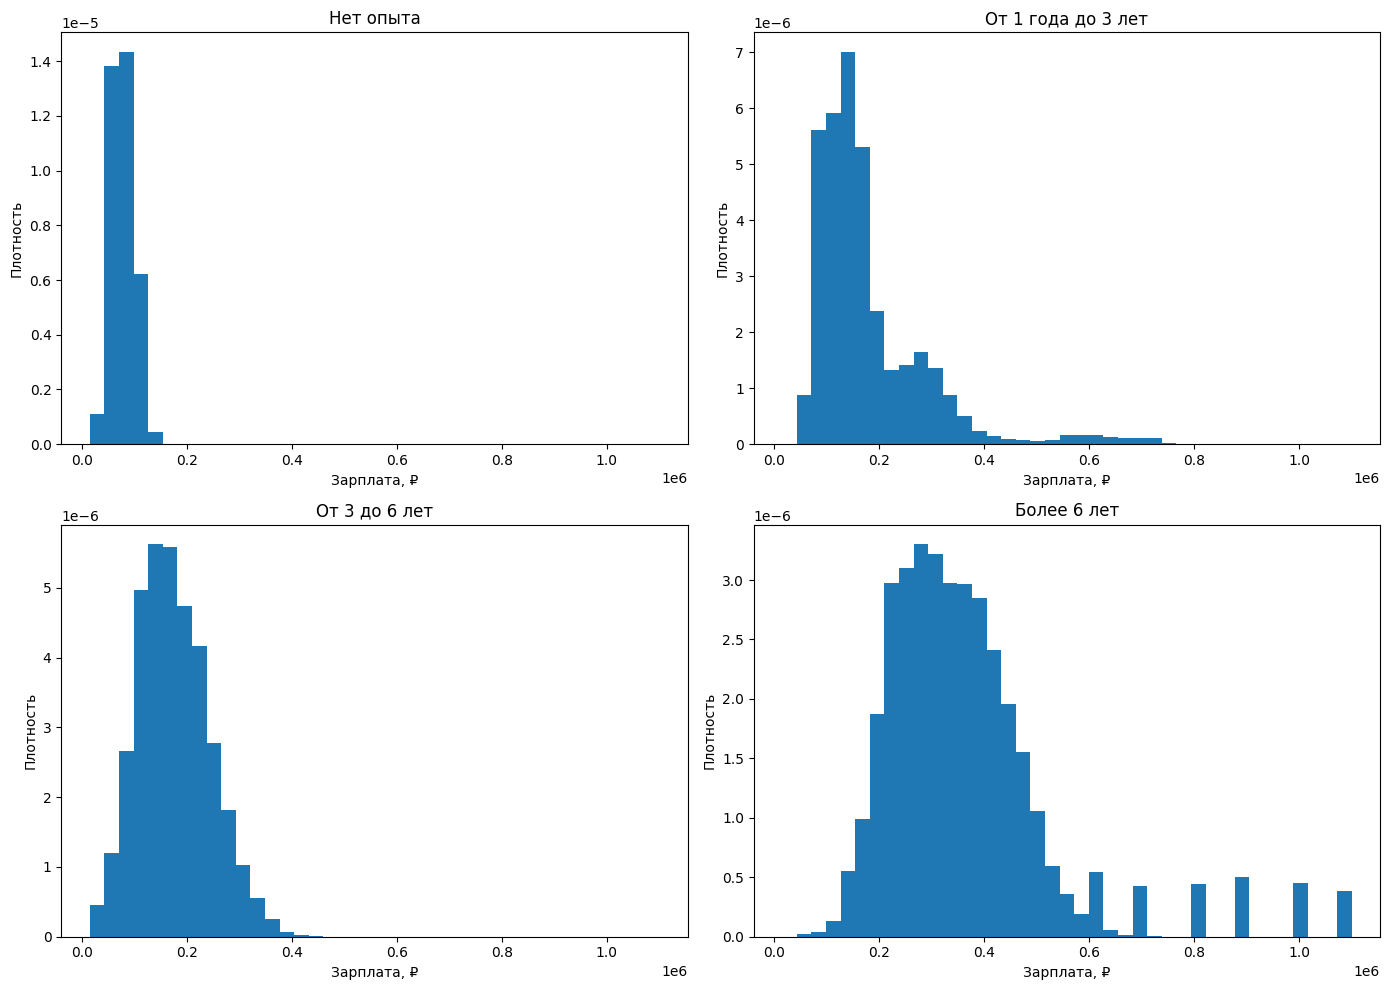

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

bins = np.linspace(
    df_clean['salary'].min(),
    df_clean['salary'].max(),
    40
)

for ax, exp in zip(axes.flatten(), experience_order):
    values = df_clean.loc[
        df_clean['experience'] == exp,
        'salary'
    ].dropna()

    ax.hist(values, bins=bins, density=True)
    ax.set_title(exp)
    ax.set_xlabel('Зарплата, ₽')
    ax.set_ylabel('Плотность')

plt.tight_layout()
plt.show()

### Вывод по распределениям

С ростом требуемого опыта распределение зарплат в целом смещается вправо,
а разброс увеличивается. Наиболее компактное распределение наблюдается
для вакансий без опыта, тогда как для группы 6+ лет характерен самый широкий
диапазон зарплат.

Для группы «От 1 года до 3 лет» особенно заметен правый хвост распределения,
что согласуется с существенной разницей между средней и медианной зарплатой.

## 7. B1

Рассчитаем коэффициент асимметрии (skewness) для каждой группы опыта.

In [59]:
skewness_by_exp = (
    df_clean
    .dropna(subset=['salary'])
    .groupby('experience')['salary']
    .skew()
    .reindex(experience_order)
)

skewness_by_exp.round(3)

,salary
experience,
Нет опыта,0.238
От 1 года до 3 лет,2.288
От 3 до 6 лет,0.398
Более 6 лет,1.962


Во всех группах коэффициент асимметрии положительный, то есть распределения
имеют правый хвост.

Наиболее сильная правосторонняя асимметрия наблюдается для вакансий
с опытом 1–3 года (2.288) и более 6 лет (1.962).

Это означает, что в этих группах присутствует относительно небольшое число
высокооплачиваемых вакансий, заметно удалённых от основной массы наблюдений.

## 8. B2

Положительная асимметрия объясняет, почему во всех группах средняя зарплата
выше медианной: высокие значения в правом хвосте сильнее влияют на среднее,
тогда как медиана остаётся устойчивой к таким наблюдениям.

Чем выше skewness, тем сильнее обычно это расхождение.

## 9. B3

Чтобы сравнить разброс зарплат между группами опыта, используем несколько метрик.

Стандартное отклонение показывает абсолютный разброс значений вокруг среднего,
но зависит от масштаба зарплат.

Межквартильный размах показывает ширину центральных 50% наблюдений
и меньше чувствителен к крайним значениям.

Также посчитаем коэффициент вариации (CV = std / mean), чтобы сравнить
относительный разброс между группами с разным уровнем зарплат.

In [60]:
dispersion = salary_stats.copy()

dispersion['IQR'] = (
    dispersion['p75'] - dispersion['p25']
)

dispersion['CV'] = (
    dispersion['std'] / dispersion['mean']
)

dispersion[['std', 'IQR', 'CV']]

,std,IQR,CV
experience,,,
Нет опыта,21262,34062,0.270695
От 1 года до 3 лет,111117,96908,0.616587
От 3 до 6 лет,68168,95000,0.389202
Более 6 лет,172368,167500,0.465459


### Вывод по B3

В абсолютном выражении наибольший разброс зарплат наблюдается в группе
«Более 6 лет»: она имеет максимальные стандартное отклонение и IQR.

Однако если учитывать различия в среднем уровне зарплат, наиболее высокая
относительная вариативность наблюдается в группе «От 1 года до 3 лет»
(CV ≈ 0.62).

Для кандидата это означает, что предсказывать будущую зарплату только по уровню
опыта недостаточно. Особенно для группы 1–3 года диапазон возможных зарплат
очень широк, поэтому дополнительно нужно учитывать другие факторы:
город, тип занятости, компанию, стек и уровень позиции.

## 10. C1

Для описания типичной зарплаты во всех группах опыта предпочтительнее использовать медиану.

Во всех группах распределения имеют положительную асимметрию, а среднее значение выше медианного => относительно небольшое число высокооплачиваемых вакансий смещает среднее вверх.

Наиболее выражен этот эффект в группах «От 1 года до 3 лет» и «Более 6 лет», где коэффициент асимметрии максимален.

Таким образом, медиана лучше отражает зарплату, характерную для типичной вакансии.

## 11. C2

Доверять одной цифре без описания методологии ее вычисления и перечня учтенных факторов, конечно, не стоит.

Для того, чтобы этой цифре можно было доверять, необходимо знать:
- какая выборка использовалась;
- как обрабатывались вакансии с некорректно отображенными зарплатными данными;
- как учитывались выбросы и ошибки;
- по каким городам и типам занятости собраны данные;
- какой период охватывает выборка;
- используется ли среднее или медиана.


## 12. C3

По описательным статистикам группа «От 3 до 6 лет» имеет более высокие показатели, но их недостаточно, чтобы утверждать о статистически значимом различии между группами.

Для строгой проверки необходимо сформулировать статистическую гипотезу и применить тест различий между распределениями.

Также полезно оценить величину эффекта и доверительный интервал разницы,
а не ограничиваться только p-value.

## 13. D1

Для Васи, имеющего 1 год опыта, наиболее релевантна группа
«От 1 года до 3 лет».

В качестве базового ориентира на переговорах разумнее использовать медианную
зарплату, а не среднее значение.

Распределение в этой группе сильно скошено вправо (skewness = 2.288),
поэтому среднее повышается за счёт относительно небольшого числа
высокооплачиваемых вакансий и хуже отражает типичное предложение.

При этом одной цифрой рынок описывать не стоит: центральные 50% наблюдений
находятся примерно в диапазоне 110–207 тыс.. Поэтому 147,5 тыс. следует
интерпретировать как ориентир типичной вакансии, а не как точную ожидаемую
зарплату конкретного кандидата.

## 14. D2

Для группы «От 1 года до 3 лет» относительный разброс зарплат самый высокий.

Это означает, что по одному только опыту зарплату Васи предсказать трудно, так как внутри группы есть широкий диапазон предложений, а распределение сильно скошено вправо.

Наименьшая неопределённость наблюдается у вакансий без опыта. У более опытных специалистов разброс снова возрастает.

Для стратегии поиска это означает, что Васе не стоит ориентироваться на одну
рыночную цифру. Лучше рассматривать вилку и сравнивать предложения с учётом
города, типа занятости, компании, стека и уровня ответственности.

## 15. D3

1. Использовать медиану около 147,5 тыс. как базовый ориентир по зарплате, но обсуждать офферы в контексте диапазона около 110–207 тыс..

2. Не оценивать предложение только по уровню опыта: в группе 1–3 года разброс зарплат очень высокий, поэтому важно учитывать остальные факторы (компанию, город, тип занятости и т. д.)

3. Для более точной оценки своей ожидаемой зарплаты собрать дополнительную выборку по максимально похожим вакансиям: тот же город, специализация, формат работы и стек.